# Data Quality Assessment & Cleaning — Transactions

**Table:** `Transactions` — 20,000 transactions across 2017.

The table the RFM model is built on, so every decision here moves the final segment counts.
Four things to settle:

1. `product_first_sold_date` is stored as a number, not a date
2. 197 rows have no product information at all 
3. 179 transactions were cancelled — do they count as revenue?
4. There is no profit column, and the project needs one

The third question is the one that matters. Recency, frequency and monetary value are all
measured from this table, so counting a cancelled order as a purchase would move a customer
into a better segment than they belong in.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_excel('Raw_data.xlsx', sheet_name='Transactions')
print(f'{df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

20,000 rows x 13 columns


,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,1,2,2950,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,71.49,53.62,41245.0
1,2,3,3120,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701.0
2,3,37,402,2017-10-16,0.0,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361.0
3,4,88,3135,2017-08-31,0.0,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10,36145.0
4,5,78,787,2017-10-01,1.0,Approved,Giant Bicycles,Standard,medium,large,1765.30,709.48,42226.0


## 1. First look

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           20000 non-null  int64         
 1   product_id               20000 non-null  int64         
 2   customer_id              20000 non-null  int64         
 3   transaction_date         20000 non-null  datetime64[ns]
 4   online_order             19640 non-null  float64       
 5   order_status             20000 non-null  object        
 6   brand                    19803 non-null  object        
 7   product_line             19803 non-null  object        
 8   product_class            19803 non-null  object        
 9   product_size             19803 non-null  object        
 10  list_price               20000 non-null  float64       
 11  standard_cost            19803 non-null  float64       
 12  product_first_sold_date  19803 n

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pd.DataFrame({'missing': missing, 'pct': (100 * missing / len(df)).round(2)})

,missing,pct
online_order,360,1.80
brand,197,0.98
product_line,197,0.98
product_class,197,0.98
product_size,197,0.98
standard_cost,197,0.98
product_first_sold_date,197,0.98


Two distinct groups of missing values, and they behave differently — worth checking whether
the 197 are the same rows each time.

In [4]:
product_cols = ['brand', 'product_line', 'product_class',
                'product_size', 'standard_cost', 'product_first_sold_date']

same_rows = df[product_cols].isna().all(axis=1).sum()
print(f'rows missing ALL six product fields: {same_rows}')
print(f'rows missing ANY product field:      {df[product_cols].isna().any(axis=1).sum()}')

rows missing ALL six product fields: 197
rows missing ANY product field:      197


The same 197 rows are missing all six product fields together. That is one broken product
record, not six unrelated gaps — the transaction exists but the product it points to does not.

`online_order` is a separate 360 rows.

## 2. Basic checks: dates, prices, duplicates

In [5]:
print('transaction date range:', df['transaction_date'].min().date(),
      '->', df['transaction_date'].max().date())
print('unique customers:', df['customer_id'].nunique())
print('duplicate rows:', df.duplicated().sum())
print('duplicate transaction_id:', df['transaction_id'].duplicated().sum())
print()
print(df[['list_price', 'standard_cost']].describe().T[['min', 'mean', 'max']])

transaction date range: 2017-01-01 -> 2017-12-30
unique customers: 3494
duplicate rows: 0
duplicate transaction_id: 0

                 min         mean      max
list_price     12.01  1107.829449  2091.47
standard_cost   7.21   556.046951  1759.85


**The data covers 2017 only** — one calendar year, not the three years the demographics
table's `past_3_years_bike_related_purchases` column might suggest. That column is a
self-reported customer attribute, not a transaction count, and the two should never be added
together.

It also fixes the reference date for recency: the RFM model measures 'days since last
purchase' as at the end of this window, not as at today.

## 3. Issue: `product_first_sold_date` is a number

The column is `float64`. The values are Excel serial dates — days elapsed since 1899-12-30.

In [6]:
print('dtype:', df['product_first_sold_date'].dtype)
print('sample values:', df['product_first_sold_date'].dropna().head(3).tolist())

dtype: float64
sample values: [41245.0, 41701.0, 36361.0]


In [7]:
df['product_first_sold_date'] = pd.to_datetime(
    df['product_first_sold_date'], unit='D', origin='1899-12-30'
)

print('after conversion:', df['product_first_sold_date'].dtype)
print('range:', df['product_first_sold_date'].min().date(),
      '->', df['product_first_sold_date'].max().date())

after conversion: datetime64[ns]
range: 1991-01-21 -> 2016-12-06


Products first sold between 1991 and 2017, which is plausible for a bike retailer's catalogue.

The origin matters: `1899-12-30`, not `1900-01-01`. Excel treats 1900 as a leap year, which it
was not, so using the intuitive origin puts every date two days out.

## 4. Decision: cancelled orders are not revenue

The `order_status` column marks some transactions as cancelled.

In [8]:
df['order_status'].value_counts()

order_status
Approved     19821
Cancelled      179
Name: count, dtype: int64

179 cancelled transactions, 0.9% of the table.

**A cancelled order is not a purchase.** Leaving them in would:

- inflate a customer's *frequency*, making them look more loyal than they are
- inflate their *monetary* value with money that was never taken
- improve their *recency* if the cancellation is their most recent activity

All three push a customer into a better segment than they have earned, which is the opposite
of what a targeting model should do.

**Action:** keep approved transactions only. The cancelled count is reported rather than
silently dropped.

In [9]:
cancelled = (df['order_status'] == 'Cancelled').sum()
df = df[df['order_status'] == 'Approved'].drop(columns=['order_status'])

print(f'removed {cancelled} cancelled transactions')
print(f'{len(df):,} approved transactions remain')

removed 179 cancelled transactions
19,821 approved transactions remain


## 5. Decision: transactions with no product

197 rows point at a product that has no record. They still have a `list_price`, so the sale
and its value are real — it is the product metadata that is missing.

In [10]:
no_product = df['brand'].isna()
print(f'transactions with no product record: {no_product.sum()}')
print(f'their combined value: ${df.loc[no_product, "list_price"].sum():,.0f}')
print(f'customers affected: {df.loc[no_product, "customer_id"].nunique()}')

transactions with no product record: 196
their combined value: $214,701
customers affected: 191


**Action: keep them.**

These are real sales worth real money to real customers. Dropping them would remove revenue
from the RFM model and understate those customers' value — a customer penalised because the
product catalogue is incomplete is a customer wrongly segmented.

The consequence is that product-level charts must exclude them explicitly, since they have no
brand to group by. `standard_cost` is also missing for these rows, so profit is null rather
than zero — an unknown margin, not a zero margin.

In [11]:
df['brand'] = df['brand'].fillna('Unknown')
df['product_line'] = df['product_line'].fillna('Unknown')
df['product_class'] = df['product_class'].fillna('Unknown')
df['product_size'] = df['product_size'].fillna('Unknown')

print('remaining nulls:')
print(df.isna().sum()[df.isna().sum() > 0].to_string())

remaining nulls:
online_order               354
standard_cost              196
product_first_sold_date    196


`standard_cost`, `product_first_sold_date` and `online_order` are deliberately left null.
Filling a cost with zero would report a 100% margin on 197 sales.

## 6. Derive `Profit`

The table has a selling price and a cost but no margin, and the dashboard needs one.

In [12]:
df['Profit'] = df['list_price'] - df['standard_cost']

print(df[['list_price', 'standard_cost', 'Profit']].describe().T[['min', 'mean', 'max']])
print()
print(f'transactions with a loss: {(df["Profit"] < 0).sum()}')
print(f'profit could not be computed: {df["Profit"].isna().sum()} (missing standard_cost)')

                 min         mean      max
list_price     12.01  1107.623061  2091.47
standard_cost   7.21   555.821210  1759.85
Profit          4.80   551.923772  1702.55

transactions with a loss: 0
profit could not be computed: 196 (missing standard_cost)


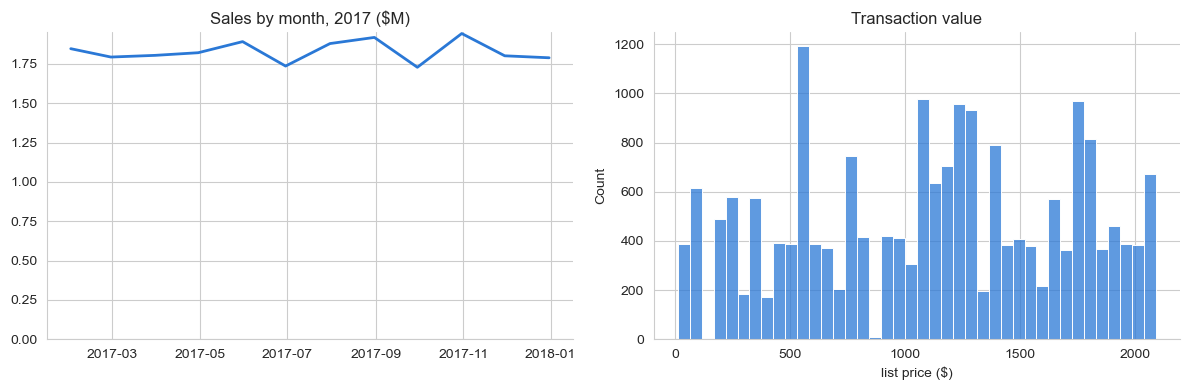

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

monthly = df.set_index('transaction_date').resample('ME')['list_price'].sum() / 1e6
axes[0].plot(monthly.index, monthly.values, color='#2a78d6', linewidth=2)
axes[0].set_title('Sales by month, 2017 ($M)')
axes[0].set_ylim(bottom=0)

sns.histplot(df['list_price'], bins=40, color='#2a78d6', ax=axes[1])
axes[1].set_title('Transaction value')
axes[1].set_xlabel('list price ($)')

sns.despine()
plt.tight_layout()
plt.show()

## 7. Define the analysis population

One population, stated once, used by everything downstream. Every headline figure in this
project is computed on exactly this set, so the customer count and the sales total always
reconcile with each other.

In [14]:
demo = pd.read_csv('CustomerDemographic_Cleaned.csv')

in_scope = df['customer_id'].isin(demo['customer_id'])
print(f'transactions from customers not in the cleaned demographics: {(~in_scope).sum()}')

df = df[in_scope]

print()
print(f'ANALYSIS POPULATION')
print(f'  transactions : {len(df):,}')
print(f'  customers    : {df["customer_id"].nunique():,}')
print(f'  total sales  : ${df["list_price"].sum():,.0f}')
print(f'  total profit : ${df["Profit"].sum():,.0f}')
print(f'  window       : {df["transaction_date"].min().date()} to {df["transaction_date"].max().date()}')

transactions from customers not in the cleaned demographics: 20

ANALYSIS POPULATION
  transactions : 19,801
  customers    : 3,490
  total sales  : $21,927,608
  total profit : $10,818,682
  window       : 2017-01-01 to 2017-12-30


## 8. Cleaned output

In [15]:
df.to_csv('Transactions_Cleaned.csv', index=False)
print(f'saved Transactions_Cleaned.csv — {len(df):,} rows x {df.shape[1]} columns')
df.head()

saved Transactions_Cleaned.csv — 19,801 rows x 13 columns


,transaction_id,product_id,customer_id,transaction_date,online_order,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,Profit
0,1,2,2950,2017-02-25,0.0,Solex,Standard,medium,medium,71.49,53.62,2012-12-02,17.87
1,2,3,3120,2017-05-21,1.0,Trek Bicycles,Standard,medium,large,2091.47,388.92,2014-03-03,1702.55
2,3,37,402,2017-10-16,0.0,OHM Cycles,Standard,low,medium,1793.43,248.82,1999-07-20,1544.61
3,4,88,3135,2017-08-31,0.0,Norco Bicycles,Standard,medium,medium,1198.46,381.10,1998-12-16,817.36
4,5,78,787,2017-10-01,1.0,Giant Bicycles,Standard,medium,large,1765.30,709.48,2015-08-10,1055.82


## Summary of changes

| # | Issue | Action | Records affected |
|---|---|---|---|
| 1 | `product_first_sold_date` stored as an Excel serial number | converted to datetime | all |
| 2 | 179 cancelled transactions | removed — a cancellation is not a purchase | 179 |
| 3 | 197 transactions with no product record | **kept**, product fields filled `Unknown` | 197 |
| 4 | No margin column | derived `Profit` = list price − standard cost | all |
| 5 | Transactions from customers not in the cleaned demographics | removed | few |

**Left null on purpose:** `standard_cost` and `Profit` for the 197 product-less rows, and
`online_order` for 360 rows. Filling a missing cost with zero would report those sales at a
100% margin.

**Worth knowing:** the transaction window is **2017 only**. `past_3_years_bike_related_purchases`
in the demographics table is a self-reported customer attribute covering a different period and
must never be added to a transaction count.